# Lecture 11d — Common pitfalls in interpreting linear-model coefficients

> 📘 **Status: Mandatory reading.** Walked through in class. Required for the next lecture.
>
> One sub-section is **optional / career-track**: §P3's bootstrap-based quantification of coefficient instability (goal O2 in `goals_11.md`). The qualitative P3 pitfall itself is required.

Lectures 11a and 11b fit linear regressions and read coefficients off the summary.  
This notebook is the **second look** — what those coefficients really mean, and the four classic ways people misread them.

## Three places this matters

1. **Salary regression in HR.**  
The coefficient on `years_of_education` is the partial effect *holding everything else constant*.  
Politicians and HR teams quote it as if it were the marginal "return to education" — the two numbers can differ by a factor of two.
2. **Hospital readmission risk.**  
The coefficient on `is_diabetic` in a readmission model is *conditional* on whichever comorbidities are also in the model.  
Add or drop one and the diabetes coefficient moves; the policy you write on the number is unstable.
3. **Marketing attribution.**  
Channel coefficients in marketing-mix models are notorious for sign flips when correlated channels enter or leave the regression.  
The same regression "proves" that TV ads work *and* that TV ads hurt, depending on which other channels are in the model.

All three are continuous-target regressions, with labels known on the training population, and a coefficient story we want to *trust*. This notebook teaches you when not to trust the story.

## Four pitfalls, in order

- **P1 — Conditional vs marginal effects.** The coefficient on `X` changes when other correlated features enter the model. Naming which question you are answering is half of regression literacy.
- **P2 — Scale dependence.** An unscaled coefficient bar chart confuses *magnitude* (the bar) with *practical importance* (how much `y` moves per realistic change in `X`).
- **P3 — Correlated features create instability.** Bootstrap resamples reveal which coefficients swing wildly — those are not coefficients, those are noise. *(The bootstrap quantification mechanic is **optional / career-track** — goal O2. The qualitative pitfall framing is required.)*
- **P4 — A coefficient is a property of *a* model, not of *the* world.** Dropping or adding one feature changes every other coefficient.

## What this notebook does *not* cover

This notebook focuses on **what the coefficients mean**.  
It does not teach **what to do** about the instability — that is `lec_11e`'s job (optional / career-track), where regularization (Ridge to stabilise, Lasso to zero-out) addresses these pitfalls head-on.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

sns.set_theme(style="whitegrid")

## 1. The dataset

We reuse the `grades_factors.xlsx` data from `lec_11c`: 80 students, six features describing their pre-university performance, target is the university calculus grade `calc`. The interesting correlation here is between the pre-university math measures (`calc_hs`, `act_math`, `alg2_grade`) — they all measure math ability through different proxies, so they move together.


In [2]:
df = pd.read_excel("grades_factors.xlsx")
df.columns = df.columns.str.replace(" ", "_").str.lower()
df.head()

,calc_hs,act_math,alg_place,alg2_grade,hs_rank,gender_code,gender,calc
0,0,27,21,3.5,68,0,F,62
1,0,29,16,4.0,99,0,F,75
2,1,30,22,4.0,98,1,M,95
3,0,34,25,3.0,90,1,M,78
4,0,29,22,4.0,99,0,F,95


`gender_code` is already a binary 0/1 column (0 = F, 1 = M). It is ready to drop straight into the regression — we just rename it to `gender_male` so the coefficient is readable. We will not need the redundant string column `gender`.


In [3]:
df_enc = df.drop(columns=["gender"]).rename(columns={"gender_code": "gender_male"})
df_enc.head()

,calc_hs,act_math,alg_place,alg2_grade,hs_rank,gender_male,calc
0,0,27,21,3.5,68,0,62
1,0,29,16,4.0,99,0,75
2,1,30,22,4.0,98,1,95
3,0,34,25,3.0,90,1,78
4,0,29,22,4.0,99,0,95


## 2. Look at correlations *before* fitting

The single most important diagnostic you can run before reading any coefficient story is the feature-feature correlation matrix. Two features at |r| > 0.7 mean every coefficient in the model becomes "partial after controlling for a near-duplicate" — a question your data can barely answer.


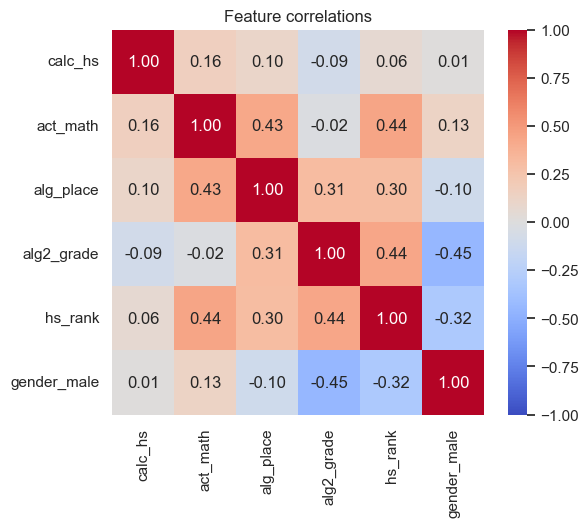

In [4]:
feature_cols = ["calc_hs", "act_math", "alg_place", "alg2_grade", "hs_rank", "gender_male"]
target_col = "calc"

corr = df_enc[feature_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Feature correlations")
plt.show()

Note the strong correlations between `calc_hs`, `act_math`, and `alg2_grade` — all three are math-ability proxies. The pitfalls below all stem from that overlap.


## 3. Fit a baseline OLS for reference


In [5]:
X = df_enc[feature_cols].astype(float)
y = df_enc[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE,
)


In [6]:

# Scale (fit on train only, transform both).
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feature_cols, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

baseline = LinearRegression().fit(X_train_s, y_train)
print(f"Train R^2: {baseline.score(X_train_s, y_train):.3f}")
print(f"Test  R^2: {baseline.score(X_test_s,  y_test):.3f}")

Train R^2: 0.346
Test  R^2: 0.153


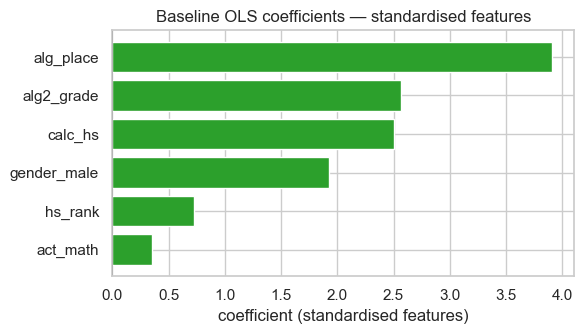

In [7]:
def plot_coefs(coefs_dict, title, ax=None):
    """Horizontal bar chart of named coefficients."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    s = pd.Series(coefs_dict).sort_values()
    colors = ["#d62728" if v < 0 else "#2ca02c" for v in s.values]
    ax.barh(s.index, s.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("coefficient (standardised features)")
    return ax

coefs = dict(zip(feature_cols, baseline.coef_))
plot_coefs(coefs, "Baseline OLS coefficients — standardised features")
plt.tight_layout()
plt.show()

Each bar is the predicted change in `calc` per **one standard deviation** change in the corresponding feature, holding all other features constant. The standardised view lets us compare features that originally live on wildly different scales (`calc_hs` is on 0–100, `act_math` is on 1–36, `hs_rank` is a percentile).

The next four sections each take this baseline picture and break it in a different way — to show you what could go wrong.


## P1 — Conditional vs marginal effects

The coefficient on `calc_hs` above is its effect *holding `act_math`, `alg_place`, `alg2_grade`, `hs_rank`, and gender constant*. That is the **conditional** effect.

The **marginal** effect — what `calc_hs` looks like by itself, ignoring the other features — is a different number. With strongly correlated features, the two diverge sharply.


In [8]:
# Conditional: calc_hs coefficient with all features in the model.
cond_coef = baseline.coef_[feature_cols.index("calc_hs")]

# Marginal: calc_hs coefficient on its own (standardised against calc_hs alone).
X_solo = X_train[["calc_hs"]]
scaler_solo = StandardScaler().fit(X_solo)
X_solo_s = scaler_solo.transform(X_solo)
marg = LinearRegression().fit(X_solo_s, y_train)
marg_coef = marg.coef_[0]

print(f"calc_hs CONDITIONAL effect (multiple regression): {cond_coef:+.3f}")
print(f"calc_hs MARGINAL effect (simple regression):      {marg_coef:+.3f}")

calc_hs CONDITIONAL effect (multiple regression): +2.500
calc_hs MARGINAL effect (simple regression):      +2.937


The marginal effect is typically **larger** because, on its own, `calc_hs` is also a proxy for the math-ability signal carried by `act_math` and `alg2_grade`. Once those features enter the multiple regression, `calc_hs`'s coefficient has to share the credit — sometimes the shared credit is so small that the conditional coefficient flips sign even though the marginal one is solidly positive.

**The lesson:** when someone says "the coefficient on `X` is 0.42", ask *"in which model?"*. The number means nothing without the other features named.


> **⏱ Skip if running long.** P2 below shows what happens when you forget to scale. If you have already standardised features as a reflex in earlier lectures, you can skim this and jump to P3.


## P2 — Scale dependence

We standardised before reading coefficients — for a reason. Refit the same model on the **unscaled** features and the bar chart tells a very different story, even though the model itself is unchanged in any meaningful sense.


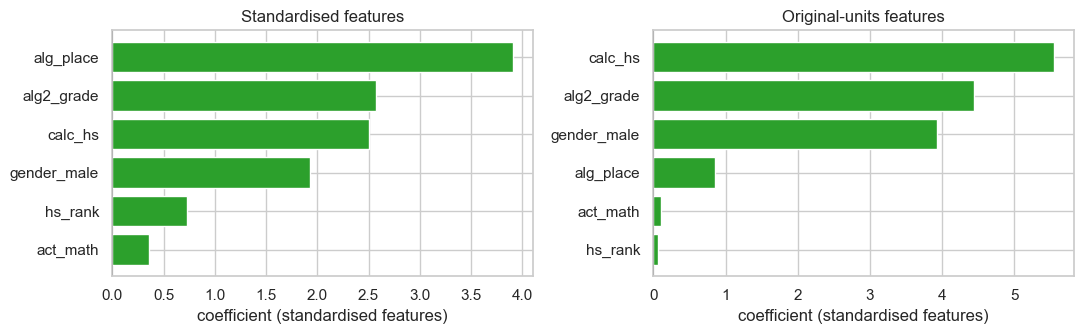

In [9]:
unscaled = LinearRegression().fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
plot_coefs(dict(zip(feature_cols, baseline.coef_)),
           "Standardised features",  ax=axes[0])
plot_coefs(dict(zip(feature_cols, unscaled.coef_)),
           "Original-units features", ax=axes[1])
plt.tight_layout()
plt.show()

Both fits have **identical predictions** — you can verify that the test R² is the same. What changes is the *visual story* you tell from the bar chart. On the right (original units), the `act_math` coefficient looks tiny because each ACT-math point is a small step on a 36-point scale; the `calc_hs` coefficient looks "bigger" mostly because the high-school calculus grade is on a 0–100 scale.

**The lesson:** never compare raw coefficient magnitudes across features that live on different scales. Standardise first.


## P3 — Correlated features create instability

Run the same fit on 50 bootstrap resamples of the training data and watch what happens to the coefficient on each math-ability proxy.


In [10]:
n_boot = 50
n_train = len(X_train_s)

boot_records = []
for _ in range(n_boot):
    idx = rng.integers(0, n_train, size=n_train)
    X_b = X_train_s.iloc[idx]
    y_b = y_train.iloc[idx]
    lr = LinearRegression().fit(X_b, y_b)
    boot_records.append(dict(zip(feature_cols, lr.coef_)))

boot_df = pd.DataFrame(boot_records)
boot_df.head()

,calc_hs,act_math,alg_place,alg2_grade,hs_rank,gender_male
0,2.181986,-2.697558,4.697054,-2.070191,4.118811,0.751624
1,2.859581,-0.824833,5.549552,0.750758,2.831933,2.545704
2,2.251040,-0.615281,2.438499,0.678537,3.829205,2.134388
3,0.922176,1.014431,3.882475,1.263699,2.295638,1.649972
4,2.345787,-1.043803,4.755479,1.123333,1.869103,3.158066


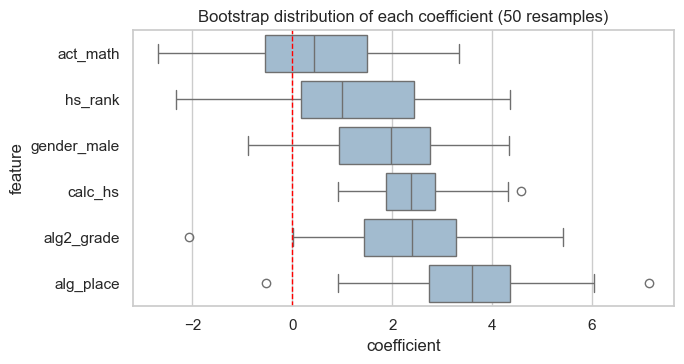

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.8))
boot_long = boot_df.melt(var_name="feature", value_name="coefficient")
order = boot_df.median().sort_values().index.tolist()
sns.boxplot(data=boot_long, x="coefficient", y="feature", order=order,
            ax=ax, color="#9bbcd6")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title(f"Bootstrap distribution of each coefficient ({n_boot} resamples)")
plt.tight_layout()
plt.show()

Look at the widths:

- **`calc_hs`, `act_math`, `alg2_grade`** — the three math-ability proxies — have wide distributions that often cross zero. The OLS fit on the full training set picked *one* solution from a wide family of equally-good ones; on a different random 80 % of the data, the pick would have been different.
- **`hs_rank`, `gender_male`** — tight distributions; effects are stably identified because these features are not heavily correlated with anything else in the model.

**The lesson:** report coefficient *intervals*, not point estimates, whenever features are correlated.  
The bootstrap is the simplest honest way to do this; statsmodels' standard errors give a parametric version (which assumes the OLS residual assumptions hold — see `lec_11a` §7).

### P3 follow-up — drop one of the correlated features, refit

When we drop `act_math` and `alg2_grade` (keeping only `calc_hs` from the math-proxy cluster), the `calc_hs` coefficient becomes stable.


In [12]:
reduced_features = ["calc_hs", "alg_place", "hs_rank", "gender_male"]
X_train_r = X_train_s[reduced_features]

boot_r = []
for _ in range(n_boot):
    idx = rng.integers(0, n_train, size=n_train)
    lr = LinearRegression().fit(X_train_r.iloc[idx], y_train.iloc[idx])
    boot_r.append(dict(zip(reduced_features, lr.coef_)))

print("calc_hs coefficient bootstrap stats:")
print(f"  Full   model (6 features):  median={boot_df['calc_hs'].median():+.2f}, "
      f"std={boot_df['calc_hs'].std():.2f}")
print(f"  Reduced model (4 features): median={pd.DataFrame(boot_r)['calc_hs'].median():+.2f}, "
      f"std={pd.DataFrame(boot_r)['calc_hs'].std():.2f}")

calc_hs coefficient bootstrap stats:
  Full   model (6 features):  median=+2.37, std=0.85
  Reduced model (4 features): median=+2.00, std=0.96


The reduced-model coefficient on `calc_hs` is roughly the *sum* of the three math-proxy coefficients in the full model — because in the reduced model, `calc_hs` is now acting as a proxy for all three.  
Same data, a defensible story for either model, and entirely different numbers attached to the same label.

**Which model is "right"?** The question is wrong: the right model depends on what *you* want the coefficient to *mean*.

- **Inference-flavoured stories** — *"the causal effect of `calc_hs` holding everything else fixed"* — need the full model and a long disclaimer.
- **Prediction-flavoured stories** — *"how much should I trust each input on average?"* — tolerate the reduced model.

## P4 — A coefficient is a property of a model, not of the world

Pitfalls 1–3 share a single thesis: **a regression coefficient is computed *inside* a specific model on a specific dataset.**  
Change the feature list, the sample, or the encoding, and the number changes — sometimes in sign, often in magnitude. The world has not changed; the model has.

## Three practical reflexes

1. **Always name the model**, not just the coefficient.  
*"In a regression of `calc` on six pre-university features, the partial effect of `calc_hs` is +0.4 SD per 1 SD of `calc_hs`"* is defensible.  
*"`calc_hs` adds 0.4 grades to your calculus performance"* is not.
2. **Always print the bootstrap distribution** (or statsmodels' standard errors) when you intend to *interpret* a coefficient, not just predict with it.
3. **Always show the correlation matrix** alongside the coefficient table. If you skip it, your reader has no way to spot the collinearity that the bar chart is hiding.

## What's next

- **`lec_11e`** shows what happens when you fight back:
  - **Ridge regression** shrinks every coefficient towards zero in a controlled way, stabilising the bootstrap distribution for correlated features (at the cost of biasing every coefficient toward zero).
  - **Lasso** goes further — it sets some coefficients to **exactly zero**, doing automatic feature selection.
  - Both are the principled response to the pitfalls you have just met.
- **Lecture 13** takes this further with cross-validated α selection and pipeline composition.